In [1]:
from src import DEER, MEM_Dataset, train

import os
from pathlib import Path

import torch

In [2]:
base_path = Path(os.getcwd()) # must be in ~/DEER/ to run, TODO fix to run regardless, probably a much later fix
img_dir = base_path / 'datasets' / 'MEM' / 'stimuli'
features_file = base_path / 'datasets' / 'MEM' / 'features.csv'

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
from torchvision.transforms import v2
transform = v2.Compose([
    v2.Resize(size=(224,224)),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
dataset = MEM_Dataset(features_file, img_dir, transform)

In [5]:
from torch.utils.data import Subset

indices = list(range(0,10))
trimmed_set = Subset(dataset, indices)

trimmed_loader = torch.utils.data.DataLoader(trimmed_set, batch_size=2, shuffle=True)

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

indices = list(range(len(dataset)))

train_idx, validation_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=dataset.original_tasks
)

train_dataset = Subset(dataset, train_idx)
validation_dataset = Subset(dataset, validation_idx)

print(len(train_dataset))
print(len(validation_dataset))

2148
537


epoch 1 | train_loss: 0.6934, train_accuracy: 0.5070 | val_loss: 0.6897, val_accuracy: 0.5065
epoch 2 | train_loss: 0.6778, train_accuracy: 0.5917 | val_loss: 0.6650, val_accuracy: 0.6406
epoch 3 | train_loss: 0.6638, train_accuracy: 0.6145 | val_loss: 0.6555, val_accuracy: 0.6704
epoch 4 | train_loss: 0.6568, train_accuracy: 0.6429 | val_loss: 0.6667, val_accuracy: 0.6052
epoch 5 | train_loss: 0.6496, train_accuracy: 0.6499 | val_loss: 0.6578, val_accuracy: 0.6406
epoch 6 | train_loss: 0.6541, train_accuracy: 0.6373 | val_loss: 0.6474, val_accuracy: 0.6834
epoch 7 | train_loss: 0.6450, train_accuracy: 0.6480 | val_loss: 0.6468, val_accuracy: 0.6853
epoch 8 | train_loss: 0.6450, train_accuracy: 0.6513 | val_loss: 0.6463, val_accuracy: 0.6741
epoch 9 | train_loss: 0.6461, train_accuracy: 0.6532 | val_loss: 0.6598, val_accuracy: 0.6462
epoch 10 | train_loss: 0.6419, train_accuracy: 0.6560 | val_loss: 0.6439, val_accuracy: 0.6723
epoch 11 | train_loss: 0.6406, train_accuracy: 0.6569 | val

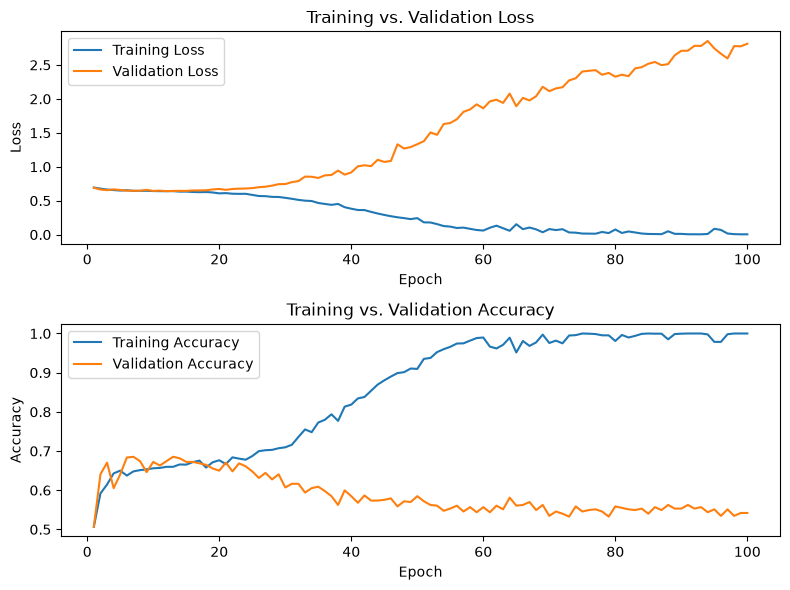

In [ ]:
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

# TODO probably abstract this cell to a method

model_name = 'DEER_baseline'
model_dir = Path(os.getcwd()) / 'models' / 'DEER_baseline'

epochs = 100
batch_size = 32
num_workers = 8
lr = 1e-3

model = DEER().to(device)
model.freeze_module('image_encoder')

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
test_loader = DataLoader(validation_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

metrics = train(model_dir, model, train_loader, test_loader, device, criterion, optimizer, epochs=epochs)

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
x = range(1, epochs + 1)

ax[0].plot(x, metrics['training_losses'], label='Training Loss')
ax[0].plot(x, metrics['validation_losses'], label='Validation Loss')
ax[0].set_title("Training vs. Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(x, metrics['training_accuracies'], label='Training Accuracy')
ax[1].plot(x, metrics['validation_accuracies'], label='Validation Accuracy')
ax[1].set_title("Training vs. Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.savefig(model_dir / f'curves.png')
plt.show()

torch.save(model.state_dict(), model_dir / 'final_model.pt')

result_map = {
    'final_train_loss' : metrics['training_losses'][-1],
    'final_train_accuracy' : metrics['training_accuracies'][-1],
    'final_val_loss' : metrics['validation_losses'][-1],
    'final_val_accuracy' : metrics['validation_accuracies'][-1],
    'epochs' : epochs,
    'optimizer' : optimizer.__class__.__name__,
    'learning_rate' : lr,
    'batch_size' : batch_size,
    'num_workers' : num_workers,
    'train_losses' : metrics['training_losses'],
    'train_accuracies' : metrics['training_accuracies'],
    'val_losses' : metrics['validation_losses'],
    'val_accuracies' : metrics['validation_accuracies'],
    'seed' : None # TODO implement seed
}

import json
with open(model_dir / 'results.json', 'w') as file:
    json.dump(result_map, file)